#**Modelo de clasificación basado en Machine Learning para la predicción de la deserción en fichas de Formación Profesional Integral del SENA**

**Realizado por:** Geraldine Suárez Solano, John Jairo Sevilla Rodríguez

**Materia:** Aprendizaje de Máquinas

**Experto temático:** John Fernando Vargas Buitrago


Este cuaderno explica, cómo construimos un modelo que predice si una ficha de formación del SENA va a tener deserción o no, usando solamente la información que se conoce al inicio de la ficha.

##**1. Entendimiento del negocio**

**¿Qué es una "ficha" del SENA?** Es un grupo de aprendices que estudian juntos un mismo programa, en un mismo periodo. Cada ficha tiene características como la regional, el centro de formación, el nivel (técnico, tecnólogo, etc.), la modalidad (presencial, virtual, a distancia) y el número de aprendices matriculados.

**¿Cuál es el problema?** Hoy en día, el SENA solo puede saber si una ficha tuvo deserción *después* de que ya ocurrió. Nuestro objetivo es anticiparnos: construir un modelo que, con la información que se conoce *al momento de crear la ficha*, prediga si esa ficha presentará deserción o no la presentará. Así, el SENA podría reforzar el acompañamiento en las fichas que el modelo marque como de mayor riesgo.

**Tipo de problema:** Clasificación binaria (dos posibles resultados: 0 = No presenta deserción, 1 = Sí presenta deserción).

In [2]:
!pip install -q imbalanced-learn # Instalamos la librería que nos permite balancear clases (SMOTE).
!pip install ydata-profiling #Se utiliza para generar reportes HTML automatizados con análisis estadísticos descriptivos completos de nuestros conjuntos de datos.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.6 MB/s eta 0:00:00


In [3]:
# ---- Librerías que vamos a usar ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

from ydata_profiling import ProfileReport
from google.colab import files

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## **2. Entendimiento de los datos**

**Dataset:** deserción_sena.xlsx

**Fuente:** Datos Abiertos Colombia - Servicio Nacional de Aprendizaje - SENA, Bogotá D.C.

**URL:** https://www.datos.gov.co/Trabajo/DESERCION-DE-LA-FORMACI-N-PROFESIONAL-INTEGRAL/u4ze-bi7k/about_data

In [4]:
ruta_archivo = "deserción_sena.xlsx"
df = pd.read_excel(ruta_archivo)

print("Número de filas (fichas):", df.shape[0])
print("Número de columnas (variables):", df.shape[1])
df.head()


Número de filas (fichas): 42080
Número de columnas (variables): 15


,CODIGO_REGIONAL,NOMBRE_REGIONAL,CODIGO_CENTRO,NOMBRE_CENTRO,IDENTIFICADOR_UNICO_FICHA,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,CODIGO_PROGRAMA,VERSION_PROGRAMA,NOMBRE_PROGRAMA_FORMACION,NIVEL_FORMACION,MODALIDAD_FORMACION,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
0,5,"""REGIONAL ANTIOQUIA""",9202,"""CENTRO DE FORMACION EN DISEÑO, CONFECCION Y M...",12475259,"""01/02/2022""","""31/01/2024""","""922502""",100,"""CONFECCION INDUSTRIAL""","""TECNOLOGO""","""PRESENCIAL""",14,1,202402
1,5,"""REGIONAL ANTIOQUIA""",9205,"""CENTRO TECNOLOGICO DEL MOBILIARIO""",12472654,"""01/02/2022""","""31/01/2024""","""122115""",100,"""GESTION ADMINISTRATIVA""","""TECNOLOGO""","""PRESENCIAL""",26,1,202402
2,5,"""REGIONAL ANTIOQUIA""",9205,"""CENTRO TECNOLOGICO DEL MOBILIARIO""",12472850,"""01/02/2022""","""31/01/2024""","""228101""",102,"""PRODUCCION DE MULTIMEDIA""","""TECNOLOGO""","""PRESENCIAL""",28,1,202402
3,73,"""REGIONAL TOLIMA""",9226,"""CENTRO DE INDUSTRIA Y CONSTRUCCION""",12472753,"""01/02/2022""","""31/01/2024""","""228106""",102,"""ANALISIS Y DESARROLLO DE SISTEMAS DE INFORMAC...","""TECNOLOGO""","""PRESENCIAL""",25,0,202402
4,11,"""REGIONAL DISTRITO CAPITAL""",9212,"""CENTRO DE MANUFACTURA EN TEXTILES Y CUERO""",12473895,"""01/02/2022""","""31/01/2024""","""934403""",1,"""QUIMICO TEXTIL""","""TECNOLOGO""","""PRESENCIAL""",25,0,202402


In [5]:
# El archivo original trae comillas dobles pegadas a los textos (por ejemplo: '\"REGIONAL TOLIMA\"').
# Esto es un detalle de formato que hay que limpiar antes de seguir, porque si no, el modelo pensaría que "REGIONAL TOLIMA" y "\"REGIONAL TOLIMA\"" son dos categorías distintas.

for columna in df.columns:
    if df[columna].dtype == object or str(df[columna].dtype).startswith('str'):
        df[columna] = df[columna].astype(str).str.strip().str.strip('"').str.strip()

df.head()


,CODIGO_REGIONAL,NOMBRE_REGIONAL,CODIGO_CENTRO,NOMBRE_CENTRO,IDENTIFICADOR_UNICO_FICHA,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,CODIGO_PROGRAMA,VERSION_PROGRAMA,NOMBRE_PROGRAMA_FORMACION,NIVEL_FORMACION,MODALIDAD_FORMACION,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
0,5,REGIONAL ANTIOQUIA,9202,"CENTRO DE FORMACION EN DISEÑO, CONFECCION Y MODA.",12475259,01/02/2022,31/01/2024,922502,100,CONFECCION INDUSTRIAL,TECNOLOGO,PRESENCIAL,14,1,202402
1,5,REGIONAL ANTIOQUIA,9205,CENTRO TECNOLOGICO DEL MOBILIARIO,12472654,01/02/2022,31/01/2024,122115,100,GESTION ADMINISTRATIVA,TECNOLOGO,PRESENCIAL,26,1,202402
2,5,REGIONAL ANTIOQUIA,9205,CENTRO TECNOLOGICO DEL MOBILIARIO,12472850,01/02/2022,31/01/2024,228101,102,PRODUCCION DE MULTIMEDIA,TECNOLOGO,PRESENCIAL,28,1,202402
3,73,REGIONAL TOLIMA,9226,CENTRO DE INDUSTRIA Y CONSTRUCCION,12472753,01/02/2022,31/01/2024,228106,102,ANALISIS Y DESARROLLO DE SISTEMAS DE INFORMACION,TECNOLOGO,PRESENCIAL,25,0,202402
4,11,REGIONAL DISTRITO CAPITAL,9212,CENTRO DE MANUFACTURA EN TEXTILES Y CUERO,12473895,01/02/2022,31/01/2024,934403,1,QUIMICO TEXTIL,TECNOLOGO,PRESENCIAL,25,0,202402


### **2.1 Recategorización de variables: de números a categorías**

| Variable | ¿Por qué es categórica y no numérica? |
|---|---|
| `CODIGO_REGIONAL` | Es un código de identificación de la regional, no una cantidad. Sumar o promediar códigos de regional no tiene ningún significado. |
| `CODIGO_CENTRO` | Igual que el anterior: es un identificador del centro de formación, no una magnitud. |
| `IDENTIFICADOR_UNICO_FICHA` | Es el identificador único de cada ficha. Es la categórica más extrema posible: cada ficha tiene su propio valor. |
| `VERSION_PROGRAMA` | Numera versiones de un programa (1, 2, 3, ...), pero la versión 3 no es "más" ni "menos" que la versión 1 en un sentido matemático; son simplemente etiquetas distintas. |
| `PERIODO` | Es un código de periodo académico, no una cantidad. |


In [6]:
columnas_a_recategorizar = [
    'CODIGO_REGIONAL', 'CODIGO_CENTRO', 'IDENTIFICADOR_UNICO_FICHA',
    'VERSION_PROGRAMA', 'PERIODO'
]

for columna in columnas_a_recategorizar:
    df[columna] = df[columna].astype('category')

# TOTAL_APRENDICES_MATRICULADOS y DESERTORES_AÑO_ACTUAL se mantienen numéricas
df['TOTAL_APRENDICES_MATRICULADOS'] = df['TOTAL_APRENDICES_MATRICULADOS'].astype(int)
df['DESERTORES_AÑO_ACTUAL'] = df['DESERTORES_AÑO_ACTUAL'].astype(int)

print("Tipos finales de las 7 variables revisadas:")
for columna in columnas_a_recategorizar + ['TOTAL_APRENDICES_MATRICULADOS', 'DESERTORES_AÑO_ACTUAL']:
    print(f"  {columna}: {df[columna].dtype}"
          + (f" ({df[columna].nunique()} categorías)" if str(df[columna].dtype) == 'category' else ""))


Tipos finales de las 7 variables revisadas:
  CODIGO_REGIONAL: category (33 categorías)
  CODIGO_CENTRO: category (117 categorías)
  IDENTIFICADOR_UNICO_FICHA: category (42080 categorías)
  VERSION_PROGRAMA: category (13 categorías)
  PERIODO: category (1 categorías)
  TOTAL_APRENDICES_MATRICULADOS: int64
  DESERTORES_AÑO_ACTUAL: int64


Por lo cual se observa que la variable **PERIODO** tiene una sola categoría (todas las fichas son del mismo periodo), por lo que sigue sin aportar información útil. **IDENTIFICADOR_UNICO_FICHA** tiene 42.080 categorías (una por cada fila), lo cual confirma aún más por qué esta variable debe excluirse del modelo. **TOTAL_APRENDICES_MATRICULADOS** y **DESERTORES_AÑO_ACTUAL** conservan su tipo numérico original.

In [7]:
# Exploramos qué tipo de variables tenemos ahora y si hay valores vacíos (nulos)
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())


Tipos de datos:
CODIGO_REGIONAL                  category
NOMBRE_REGIONAL                    object
CODIGO_CENTRO                    category
NOMBRE_CENTRO                      object
IDENTIFICADOR_UNICO_FICHA        category
FECHA_INICIO_FICHA                 object
FECHA_TERMINACION_FICHA            object
CODIGO_PROGRAMA                    object
VERSION_PROGRAMA                 category
NOMBRE_PROGRAMA_FORMACION          object
NIVEL_FORMACION                    object
MODALIDAD_FORMACION                object
TOTAL_APRENDICES_MATRICULADOS       int64
DESERTORES_AÑO_ACTUAL               int64
PERIODO                          category
dtype: object

Valores nulos por columna:
CODIGO_REGIONAL                  0
NOMBRE_REGIONAL                  0
CODIGO_CENTRO                    0
NOMBRE_CENTRO                    0
IDENTIFICADOR_UNICO_FICHA        0
FECHA_INICIO_FICHA               0
FECHA_TERMINACION_FICHA          0
CODIGO_PROGRAMA                  0
VERSION_PROGRAMA                

Esto demuestra que el dataset no tiene valores nulos. Por tanto no vamos a necesitar imputar datos faltantes, pero de todas formas sí vamos a revisar que los valores tengan sentido (por ejemplo, que no haya fichas con 0 aprendices o con más desertores que matriculados).

In [8]:
# Estadísticas descriptivas. Como varias columnas ahora son categóricas, usamos
# include='all' para ver tanto las estadísticas numéricas como los conteos de categorías.
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODIGO_REGIONAL,42080.0,33.0,11.0,5418.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_REGIONAL,42080,33,REGIONAL DISTRITO CAPITAL,5418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODIGO_CENTRO,42080.0,117.0,9302.0,1075.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_CENTRO,42080,110,CENTRO DE COMERCIO Y SERVICIOS,3386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IDENTIFICADOR_UNICO_FICHA,42080.0,42080.0,12932418.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA_INICIO_FICHA,42080,521,22/01/2024,1808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA_TERMINACION_FICHA,42080,732,16/12/2024,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODIGO_PROGRAMA,42080,2195,228118,1541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VERSION_PROGRAMA,42080.0,13.0,1.0,27695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_PROGRAMA_FORMACION,42080,2153,ANALISIS Y DESARROLLO DE SOFTWARE.,1541,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Vista rápida de las variables categóricas más importantes
for col in ['NIVEL_FORMACION', 'MODALIDAD_FORMACION']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- NIVEL_FORMACION ---
NIVEL_FORMACION
TECNICO                   16832
CURSO ESPECIAL            14285
TECNOLOGO                 10259
OPERARIO                    423
EVENTO                      142
AUXILIAR                    128
PROFUNDIZACION TECNICA       11
Name: count, dtype: int64

--- MODALIDAD_FORMACION ---
MODALIDAD_FORMACION
PRESENCIAL     32344
VIRTUAL         9592
A DISTANCIA      144
Name: count, dtype: int64



### **Reporte automático de exploración (ydata-profiling)**

Este reporte crea una página HTML con, para cada variable: su distribución, valores únicos, estadísticas descriptivas y la matriz de correlaciones entre todas las variables
**Variables que dejamos por fuera del reporte, y por qué:**
- **IDENTIFICADOR_UNICO_FICHA**: ahora que es categórica, tiene 42.080 categorías (una por fila). Incluirla no solo sería inútil, sino que haría el reporte extremadamente lento.
- **NOMBRE_PROGRAMA_FORMACION**: tiene 2.153 categorías distintas. Incluirla haría el reporte enorme y difícil de leer (ya la excluimos del modelo en la sección 3.4 por el mismo motivo).

**TOTAL_APRENDICES_MATRICULADOS** y **DESERTORES_AÑO_ACTUAL** se incluyen como variables **numéricas** (no se convierten a texto), para que el reporte muestre su distribución, media, desviación estándar, etc., tal como corresponde a su tipo real.

In [10]:
columnas_categoricas_reporte = [
    'NOMBRE_REGIONAL', 'CODIGO_REGIONAL', 'NOMBRE_CENTRO', 'CODIGO_CENTRO',
    'VERSION_PROGRAMA', 'NIVEL_FORMACION', 'MODALIDAD_FORMACION', 'PERIODO'
]
columnas_numericas_reporte = ['TOTAL_APRENDICES_MATRICULADOS', 'DESERTORES_AÑO_ACTUAL']
columnas_reporte = [c for c in columnas_categoricas_reporte + columnas_numericas_reporte if c in df.columns]

df_reporte = df[columnas_reporte].copy()
for col in columnas_categoricas_reporte:
    if col in df_reporte.columns:
        df_reporte[col] = df_reporte[col].astype(str)
# las columnas numéricas (TOTAL_APRENDICES_MATRICULADOS, DESERTORES_AÑO_ACTUAL) se dejan
# tal cual, para que ydata-profiling las trate como numéricas y no como categóricas.

perfil = ProfileReport(
    df_reporte,
    title="Reporte de perfilado - Deserción en fichas de Formación SENA",
    explorative=True,
    correlations={
        "auto": {"calculate": True},
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
        "cramers": {"calculate": True},
    },
)

perfil.to_file("reporte_ydata_profiling.html")
print("Reporte generado: reporte_ydata_profiling.html")

from google.colab import files
files.download('reporte_ydata_profiling.html')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:04<00:00,  2.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte generado: reporte_ydata_profiling.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**3. Preparación de los datos**

1. **Limpieza de errores**.
2. **Construcción de la variable objetivo**
3. **Creación de variables nuevas** (variables derivadas) a partir de las fechas.
4. **Selección de variables**: decidir cuáles sí sirven para predecir y cuáles no.
5. **Codificación**
6. **División del dataset en entrenamiento y prueba**.
7. **Escalado** de las variables numéricas.
8. **Balanceo de clases** con SMOTE.


### **3.1 Limpieza de errores**

In [11]:
# Convertimos las fechas de texto a un formato de fecha real
df['FECHA_INICIO_FICHA'] = pd.to_datetime(df['FECHA_INICIO_FICHA'], format='%d/%m/%Y', errors='coerce')
df['FECHA_TERMINACION_FICHA'] = pd.to_datetime(df['FECHA_TERMINACION_FICHA'], format='%d/%m/%Y', errors='coerce')

antes = len(df)

# Reglas de calidad: eliminamos registros que no tengan sentido de negocio. como TOTAL_APRENDICES_MATRICULADOS y DESERTORES_AÑO_ACTUAL ya son categóricas,las comparamos convirtiéndolas de vuelta a número solo para esta verificación puntual.
matriculados_num = df['TOTAL_APRENDICES_MATRICULADOS'].astype(int)
desertores_num = df['DESERTORES_AÑO_ACTUAL'].astype(int)

df = df[df['FECHA_INICIO_FICHA'].notnull() & df['FECHA_TERMINACION_FICHA'].notnull()]
df = df[df['FECHA_TERMINACION_FICHA'] >= df['FECHA_INICIO_FICHA']]
df = df[matriculados_num.reindex(df.index) > 0]
df = df[desertores_num.reindex(df.index) >= 0]
df = df[desertores_num.reindex(df.index) <= matriculados_num.reindex(df.index)]

print(f"Registros antes de la limpieza: {antes}")
print(f"Registros después de la limpieza: {len(df)}")
print(f"Registros eliminados: {antes - len(df)}")


Registros antes de la limpieza: 42080
Registros después de la limpieza: 42080
Registros eliminados: 0


Por lo cual, en este dataset en particular, todas las fechas y cantidades ya venían correctas, por lo que no se eliminó ningún registro. Aun así, este paso es indispensable, porque nos asegura que el resto del análisis parte de datos confiables.

### **3.2 Construcción de la variable objetivo**

In [12]:
# La variable que queremos predecir no viene lista en el archivo: hay que construirla, entonces tomaremos como base la variable "DESERTORES_AÑO_ACTUAL".

# Regla de negocio: si una ficha tuvo 1 o más desertores, se considera que "presenta deserción" (1).
# Si tuvo 0 desertores, se considera que "no presenta deserción" (0).

df['PRESENTA_DESERCION'] = (df['DESERTORES_AÑO_ACTUAL'].astype(int) > 0).astype(int)

print(df['PRESENTA_DESERCION'].value_counts())
print()
print("Porcentaje de cada clase:")
print((df['PRESENTA_DESERCION'].value_counts(normalize=True) * 100).round(1))


PRESENTA_DESERCION
0    31852
1    10228
Name: count, dtype: int64

Porcentaje de cada clase:
PRESENTA_DESERCION
0    75.7
1    24.3
Name: proportion, dtype: float64


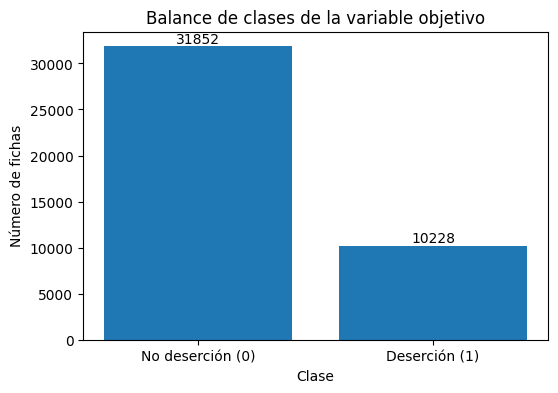

In [13]:
plt.figure(figsize=(6,4))

conteo = df['PRESENTA_DESERCION'].value_counts().sort_index()

plt.bar(['No deserción (0)', 'Deserción (1)'],conteo.values)
plt.title('Balance de clases de la variable objetivo')
plt.xlabel('Clase')
plt.ylabel('Número de fichas')

# Mostrar valores encima de cada barra
for i, valor in enumerate(conteo.values):
    plt.text(
        i,
        valor,
        str(valor),
        ha='center',
        va='bottom'
    )

plt.show()

Lo anterior permite identificar que la variable objetivo presenta una distribución de 75,7% de fichas sin deserción y 24,3% con presencia de deserción, evidenciando un desbalance moderado entre las clases. Esta diferencia puede provocar que algunos modelos tengan una mayor tendencia a predecir la clase mayoritaria, afectando la identificación de fichas con presencia de deserción.

Por esta razón, la evaluación de los modelos no se realizará únicamente con Accuracy, sino que se utilizarán métricas como F1-Score Macro, Precision Macro y Recall Macro, las cuales permiten valorar el desempeño del modelo en ambas clases. Adicionalmente, se evaluará la aplicación de técnicas de balanceo como SMOTE o ponderación de clases durante el entrenamiento, con el fin de mejorar la capacidad predictiva sobre la clase minoritaria.

### **3.3 Variables derivadas**

Las variables de fecha no serán utilizadas directamente en los modelos, debido a que los algoritmos de aprendizaje automático no interpretan fechas en su formato original. Por esta razón, vamos a generar variables derivadas con significado para el problema:

**MES_INICIO_FICHA:** representa el mes en que inicia la ficha de formación y permite analizar posibles comportamientos asociados al momento del año en que comienza el proceso formativo.

**DURACION_DIAS:** corresponde a la duración estimada de la formación en días, calculada a partir de la diferencia entre la fecha de inicio y terminación. Esta variable permite analizar si la extensión del proceso formativo puede estar relacionada con una mayor probabilidad de deserción.

In [14]:
df['MES_INICIO_FICHA'] = df['FECHA_INICIO_FICHA'].dt.month.astype(str)
df['DURACION_DIAS'] = (df['FECHA_TERMINACION_FICHA'] - df['FECHA_INICIO_FICHA']).dt.days

df[['FECHA_INICIO_FICHA','FECHA_TERMINACION_FICHA','MES_INICIO_FICHA','DURACION_DIAS']].head()


,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,MES_INICIO_FICHA,DURACION_DIAS
0,2022-02-01,2024-01-31,2,729
1,2022-02-01,2024-01-31,2,729
2,2022-02-01,2024-01-31,2,729
3,2022-02-01,2024-01-31,2,729
4,2022-02-01,2024-01-31,2,729


###**3.4 Selección de variables**

Ahora identificamos las variables seleccionadas para entrenar los modelos con su respectiva justificación.

| Variable | ¿Se usa? | Tipo | ¿Por qué? |
|---|---|---|---|
| NOMBRE_REGIONAL | Sí | Categórica | Las condiciones cambian de una región a otra |
| NOMBRE_CENTRO | Sí | Categórica | Cada centro tiene su propia gestión y capacidad |
| VERSION_PROGRAMA | Sí | Categórica | Distintas versiones pueden tener cambios en el contenido |
| NIVEL_FORMACION | Sí | Categórica | Técnico, tecnólogo, curso especial, etc. tienen dinámicas distintas |
| MODALIDAD_FORMACION | Sí | Categórica | Virtual, presencial o a distancia influyen en la permanencia |
| TOTAL_APRENDICES_MATRICULADOS | Sí | Numérica | Representa el tamaño inicial de la ficha; su magnitud (más o menos aprendices) es información útil |
| MES_INICIO_FICHA (nueva) | Sí | Categórica | Posible efecto de estacionalidad |
| DURACION_DIAS (nueva) | Sí | Numérica | Formaciones más largas pueden tener más riesgo de abandono |
| CODIGO_REGIONAL | No | Categórica | Redundante: la misma información ya está en NOMBRE_REGIONAL |
| CODIGO_CENTRO | No | Categórica | Redundante: la misma información ya está en NOMBRE_CENTRO |
| IDENTIFICADOR_UNICO_FICHA | No | Categórica (42.080 categorías) | Cada ficha tiene un valor único; imposible aprender un patrón de ahí |
| PERIODO | No | Categórica (1 sola categoría) | No aporta información para distinguir fichas |
| NOMBRE_PROGRAMA_FORMACION | No | Categórica | Demasiadas categorías distintas (más de 2.000) |
| **DESERTORES_AÑO_ACTUAL** | **No (fuga de datos)** | Numérica | Con esta variable ya sabríamos la respuesta de antemano |
| FECHA_TERMINACION_FICHA (original) | No | Fecha | Ya la resumimos en DURACION_DIAS |

In [15]:
columnas_categoricas = ['NOMBRE_REGIONAL','NOMBRE_CENTRO','VERSION_PROGRAMA',
                        'NIVEL_FORMACION','MODALIDAD_FORMACION','MES_INICIO_FICHA']
columnas_numericas = ['TOTAL_APRENDICES_MATRICULADOS', 'DURACION_DIAS']

X = df[columnas_categoricas + columnas_numericas].copy()
for col in columnas_categoricas:
    X[col] = X[col].astype(str)   # todas las categóricas las tratamos como texto

y = df['PRESENTA_DESERCION'].astype(int)

print("Forma de X (filas, columnas):", X.shape)
print("Forma de y:", y.shape)


Forma de X (filas, columnas): (42080, 8)
Forma de y: (42080,)


Se realizó la selección de las variables predictoras ($x$) y la variable objetivo ($y$) para el entrenamiento de los modelos de clasificación. Por lo cual, el conjunto de entrada quedó conformado por **42.080 registros y 8 variables predictoras**, distribuidas entre variables categóricas (**NOMBRE_REGIONAL**, **NOMBRE_CENTRO**, **VERSION_PROGRAMA**, **NIVEL_FORMACION**, **MODALIDAD_FORMACION** y **MES_INICIO_FICHA**) y variables numéricas (**TOTAL_APRENDICES_MATRICULADOS** y **DURACION_DIAS**).

Las variables categóricas fueron transformadas al tipo texto para garantizar un tratamiento adecuado durante la etapa de codificación mediante técnicas como One Hot Encoding, evitando que variables como **VERSION_PROGRAMA** o **MES_INICIO_FICHA** sean interpretadas erróneamente como valores continuos.

La variable objetivo $y$, correspondiente a **PRESENTA_DESERCION**, contiene 42.080 registros con valores binarios (0 = no presenta deserción, 1 = presenta deserción), permitiendo abordar el problema como un modelo de clasificación supervisada.

### **3.5 Codificación (convertir texto en números)**

Los modelos de Machine Learning solo entienden números. Por consiguiente, para las variables categóricas usaremos **One-Hot Encoding**: por cada categoría de una variable, se creará una columna nueva con 0 o 1.

In [16]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_categoricas_codificadas = encoder.fit_transform(X[columnas_categoricas])
nombres_columnas_codificadas = encoder.get_feature_names_out(columnas_categoricas)

X_categoricas_df = pd.DataFrame(X_categoricas_codificadas, columns=nombres_columnas_codificadas, index=X.index)
X_final = pd.concat([X_categoricas_df, X[columnas_numericas]], axis=1)

print("Número total de columnas después de codificar:", X_final.shape[1])
X_final.head()


Número total de columnas después de codificar: 180


,NOMBRE_REGIONAL_REGIONAL AMAZONAS,NOMBRE_REGIONAL_REGIONAL ANTIOQUIA,NOMBRE_REGIONAL_REGIONAL ARAUCA,NOMBRE_REGIONAL_REGIONAL ATLANTICO,NOMBRE_REGIONAL_REGIONAL BOLIVAR,NOMBRE_REGIONAL_REGIONAL BOYACA,NOMBRE_REGIONAL_REGIONAL CALDAS,NOMBRE_REGIONAL_REGIONAL CAQUETA,NOMBRE_REGIONAL_REGIONAL CASANARE,NOMBRE_REGIONAL_REGIONAL CAUCA,...,MES_INICIO_FICHA_2,MES_INICIO_FICHA_3,MES_INICIO_FICHA_4,MES_INICIO_FICHA_5,MES_INICIO_FICHA_6,MES_INICIO_FICHA_7,MES_INICIO_FICHA_8,MES_INICIO_FICHA_9,TOTAL_APRENDICES_MATRICULADOS,DURACION_DIAS
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,729
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26,729
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,729
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25,729
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25,729


In [17]:
# La variable objetivo también se codifica (aunque ya es 0/1, usamos LabelEncoder por buena práctica)
label_encoder = LabelEncoder()
y_codificada = label_encoder.fit_transform(y)
print("Clases del LabelEncoder:", label_encoder.classes_)


Clases del LabelEncoder: [0 1]


### **3.6 División en entrenamiento y prueba**

Dividimos los datos en dos partes:

- **Entrenamiento (70%)**: con esta parte el modelo "aprende".
- **Prueba (30%)**: esta parte el modelo nunca la ve durante el entrenamiento; sirve para comprobar qué tan bien generaliza a fichas nuevas.

Usamos `stratify=y` para asegurar que la proporción de fichas con y sin deserción sea parecida en ambos conjuntos.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_codificada, test_size=0.3, random_state=42, stratify=y_codificada
)

print("Registros de entrenamiento:", X_train.shape[0])
print("Registros de prueba:", X_test.shape[0])


Registros de entrenamiento: 29456
Registros de prueba: 12624


### **3.7 Escalado (solo con el conjunto de entrenamiento)**

Las variables numéricas (**TOTAL_APRENDICES_MATRICULADOS** y **DURACION_DIAS**) tienen escalas muy distintas (una va de 1 a 208, la otra de 0 a casi 1.400 días). Si no las llevamos a una misma escala, el modelo podría darle más importancia a la que tiene números más grandes, sin que eso tenga sentido.

**Punto clave (para evitar fuga de datos):** el escalador (**MinMaxScaler**) se ajusta ("aprende" los valores mínimo y máximo) **solo con el conjunto de entrenamiento**, y luego se aplica igual sobre el conjunto de prueba.

In [19]:
scaler = MinMaxScaler()

X_train_escalado = X_train.copy()
X_test_escalado = X_test.copy()

X_train_escalado[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test_escalado[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

X_train_escalado[columnas_numericas].describe()


,TOTAL_APRENDICES_MATRICULADOS,DURACION_DIAS
count,29456.000000,29456.000000
mean,0.161006,0.308343
std,0.102796,0.222909
min,0.000000,0.000000
25%,0.101449,0.023639
50%,0.125604,0.327364
75%,0.164251,0.488539
max,1.000000,1.000000


### **3.8 Balanceo de clases (SMOTE, solo en entrenamiento)**

Recordemos que solo el 24% de las fichas tienen deserción. Por tanto, usaremos **SMOTE**, el cual crea registros sintéticos de la clase minoritaria (deserción), parecidos a los reales, hasta dejar las dos clases con la misma cantidad de registros.

**Punto clave (otra vez, para evitar fuga de datos):** SMOTE se aplica **únicamente sobre el conjunto de entrenamiento**. El conjunto de prueba se deja tal cual, con su desbalance original.

In [20]:
smote = SMOTE(random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train_escalado, y_train)

print("Antes de SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("Después de SMOTE:", pd.Series(y_train_balanceado).value_counts().to_dict())


Antes de SMOTE: {0: 22296, 1: 7160}
Después de SMOTE: {1: 22296, 0: 22296}


In [21]:
# Guardamos los objetos de preparación de datos, para la app de Streamlit
joblib.dump(encoder, 'encoder.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(label_encoder, 'label_encoder.joblib')
joblib.dump(list(X_final.columns), 'columnas_modelo.joblib')
print("Objetos de preparación guardados: encoder.joblib, scaler.joblib, label_encoder.joblib, columnas_modelo.joblib")


Objetos de preparación guardados: encoder.joblib, scaler.joblib, label_encoder.joblib, columnas_modelo.joblib


## **4. Modelamiento**

Vamos a entrenar y comparar **seis modelos** de clasificación, buscando en cada uno los mejores "hiperparámetros" con `GridSearchCV`, usando validación cruzada de 5 particiones (5-Fold) y como métrica principal el **F1-Score (Macro)**.

Los modelos son:

1. **Regresión Logística** — el modelo más simple, sirve como línea base.
2. **SVM (Máquinas de Soporte Vectorial)**.
3. **Red Neuronal (MLP)**.
4. **Random Forest** (bagging).
5. **Gradient Boosting** (boosting) — usamos HistGradientBoostingClassifier, mucho más rápido con datasets grandes.
6. **Voting (ensamble)** — combina Regresión Logística, Random Forest y Gradient Boosting.

In [22]:
validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

def evaluar_modelo(modelo, X_prueba=X_test_escalado, y_prueba=y_test):
    prediccion = modelo.predict(X_prueba)
    return {
        'accuracy': round(accuracy_score(y_prueba, prediccion), 4),
        'precision_macro': round(precision_score(y_prueba, prediccion, average='macro'), 4),
        'recall_macro': round(recall_score(y_prueba, prediccion, average='macro'), 4),
        'f1_macro': round(f1_score(y_prueba, prediccion, average='macro'), 4),
    }

print("Función de evaluación lista.")


Función de evaluación lista.


In [23]:
# ----- 1) Regresión Logística -----
parametros_lr = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        parametros_lr, scoring='f1_macro', cv=validacion_cruzada, n_jobs=-1)
grid_lr.fit(X_train_balanceado, y_train_balanceado)

resultados['Regresion Logistica'] = {
    'mejores_hiperparametros': grid_lr.best_params_,
    'cv_f1_macro_mean': round(grid_lr.best_score_, 4),
    'test': evaluar_modelo(grid_lr.best_estimator_)
}
print("Regresión Logística lista ->", resultados['Regresion Logistica'])


Regresión Logística lista -> {'mejores_hiperparametros': {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}, 'cv_f1_macro_mean': np.float64(0.7399), 'test': {'accuracy': 0.7493, 'precision_macro': 0.6868, 'recall_macro': 0.7286, 'f1_macro': 0.6972}}


In [24]:
# ----- 2) SVM -----
rng = np.random.RandomState(42)
indices_muestra = rng.choice(len(X_train_balanceado), size=min(8000, len(X_train_balanceado)), replace=False)
X_train_svm = X_train_balanceado.iloc[indices_muestra]
y_train_svm = y_train_balanceado[indices_muestra]

parametros_svm = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
grid_svm = GridSearchCV(SVC(random_state=42), parametros_svm, scoring='f1_macro', cv=3, n_jobs=-1)
grid_svm.fit(X_train_svm, y_train_svm)

resultados['SVM'] = {
    'mejores_hiperparametros': grid_svm.best_params_,
    'cv_f1_macro_mean': round(grid_svm.best_score_, 4),
    'test': evaluar_modelo(grid_svm.best_estimator_)
}
print("SVM listo ->", resultados['SVM'])


SVM listo -> {'mejores_hiperparametros': {'C': 10, 'kernel': 'rbf'}, 'cv_f1_macro_mean': np.float64(0.786), 'test': {'accuracy': 0.759, 'precision_macro': 0.6906, 'recall_macro': 0.7246, 'f1_macro': 0.7013}}


In [25]:
# ----- 3) Red Neuronal (MLP) -----
parametros_mlp = {'hidden_layer_sizes': [(32,), (64, 32)], 'alpha': [0.0001, 0.001]}
grid_mlp = GridSearchCV(MLPClassifier(max_iter=300, random_state=42, early_stopping=True),
                         parametros_mlp, scoring='f1_macro', cv=3, n_jobs=-1)
grid_mlp.fit(X_train_balanceado, y_train_balanceado)

resultados['Red Neuronal'] = {
    'mejores_hiperparametros': grid_mlp.best_params_,
    'cv_f1_macro_mean': round(grid_mlp.best_score_, 4),
    'test': evaluar_modelo(grid_mlp.best_estimator_)
}
print("Red Neuronal lista ->", resultados['Red Neuronal'])


Red Neuronal lista -> {'mejores_hiperparametros': {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}, 'cv_f1_macro_mean': np.float64(0.8025), 'test': {'accuracy': 0.7695, 'precision_macro': 0.702, 'recall_macro': 0.7368, 'f1_macro': 0.7134}}


In [26]:
# ----- 4) Random Forest -----
parametros_rf = {'n_estimators': [200, 300], 'max_depth': [None, 15]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                        parametros_rf, scoring='f1_macro', cv=validacion_cruzada, n_jobs=-1)
grid_rf.fit(X_train_balanceado, y_train_balanceado)

resultados['Random Forest'] = {
    'mejores_hiperparametros': grid_rf.best_params_,
    'cv_f1_macro_mean': round(grid_rf.best_score_, 4),
    'test': evaluar_modelo(grid_rf.best_estimator_)
}
print("Random Forest listo ->", resultados['Random Forest'])


Random Forest listo -> {'mejores_hiperparametros': {'max_depth': None, 'n_estimators': 200}, 'cv_f1_macro_mean': np.float64(0.8566), 'test': {'accuracy': 0.8024, 'precision_macro': 0.7316, 'recall_macro': 0.7323, 'f1_macro': 0.7319}}


In [27]:
# ----- 5) Gradient Boosting -----
parametros_gb = {'max_iter': [150, 250], 'learning_rate': [0.05, 0.1]}
grid_gb = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                        parametros_gb, scoring='f1_macro', cv=validacion_cruzada, n_jobs=-1)
grid_gb.fit(X_train_balanceado, y_train_balanceado)

resultados['Gradient Boosting'] = {
    'mejores_hiperparametros': grid_gb.best_params_,
    'cv_f1_macro_mean': round(grid_gb.best_score_, 4),
    'test': evaluar_modelo(grid_gb.best_estimator_)
}
print("Gradient Boosting listo ->", resultados['Gradient Boosting'])


Gradient Boosting listo -> {'mejores_hiperparametros': {'learning_rate': 0.1, 'max_iter': 250}, 'cv_f1_macro_mean': np.float64(0.8564), 'test': {'accuracy': 0.8052, 'precision_macro': 0.7356, 'recall_macro': 0.7403, 'f1_macro': 0.7379}}


In [28]:
# ----- 6) Voting (ensamble de los tres modelos anteriores más robustos) -----
voting = VotingClassifier(estimators=[
    ('lr', grid_lr.best_estimator_),
    ('rf', grid_rf.best_estimator_),
    ('gb', grid_gb.best_estimator_)
], voting='soft')
voting.fit(X_train_balanceado, y_train_balanceado)

resultados['Voting'] = {'test': evaluar_modelo(voting)}
print("Voting listo ->", resultados['Voting'])


Voting listo -> {'test': {'accuracy': 0.8035, 'precision_macro': 0.7341, 'recall_macro': 0.7445, 'f1_macro': 0.7389}}


## **5. Evaluación final**

Ahora comparamos los seis modelos usando su **F1-Score (Macro)** calculado sobre el conjunto de prueba (el 30% que el modelo nunca vio durante el entrenamiento).

In [29]:
tabla_resultados = pd.DataFrame({
    modelo: {**info['test'], 'cv_f1_macro': info.get('cv_f1_macro_mean', '—')}
    for modelo, info in resultados.items()
}).T
tabla_resultados = tabla_resultados[['accuracy','precision_macro','recall_macro','f1_macro','cv_f1_macro']]
tabla_resultados = tabla_resultados.sort_values('f1_macro', ascending=False)
tabla_resultados


,accuracy,precision_macro,recall_macro,f1_macro,cv_f1_macro
Voting,0.8035,0.7341,0.7445,0.7389,—
Gradient Boosting,0.8052,0.7356,0.7403,0.7379,0.8564
Random Forest,0.8024,0.7316,0.7323,0.7319,0.8566
Red Neuronal,0.7695,0.702,0.7368,0.7134,0.8025
SVM,0.759,0.6906,0.7246,0.7013,0.786
Regresion Logistica,0.7493,0.6868,0.7286,0.6972,0.7399


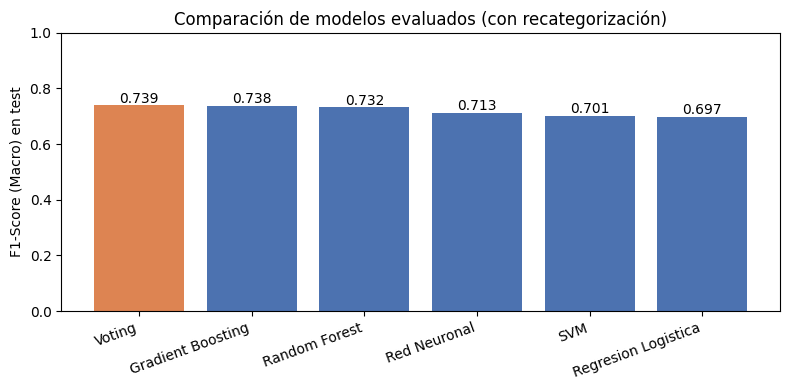

In [30]:
plt.figure(figsize=(8,4))
colores = ['#DD8452' if m == tabla_resultados.index[0] else '#4C72B0' for m in tabla_resultados.index]
barras = plt.bar(tabla_resultados.index, tabla_resultados['f1_macro'], color=colores)
plt.ylabel('F1-Score (Macro) en test')
plt.title('Comparación de modelos evaluados (con recategorización)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
for barra, valor in zip(barras, tabla_resultados['f1_macro']):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 0.01, f'{valor:.3f}', ha='center')
plt.tight_layout()
plt.show()


Por consiguiente, al evaluar los modelos surge la pregunta: **¿cuál presentó el mejor desempeño?** De acuerdo con los resultados obtenidos en el conjunto de prueba, el modelo Voting presentó el mayor F1-Score (Macro), con un valor de 0,739, seguido de Gradient Boosting (0,738) y Random Forest (0,732). Sin embargo, la diferencia entre Voting y Gradient Boosting fue mínima, de apenas 0,001 puntos, por lo que el desempeño predictivo de ambos modelos resultó prácticamente equivalente.

**Justificación:** A pesar de que Voting obtuvo el F1-Score ligeramente superior en el conjunto de prueba, se seleccionó Gradient Boosting como modelo final considerando su desempeño competitivo y sus ventajas para el despliegue. El modelo presentó un F1-Score Macro de 0,738, prácticamente igual al obtenido por Voting, pero con una estructura más sencilla y un menor tamaño del archivo serializado. Esto facilita su integración y ejecución en una aplicación web mediante Streamlit, especialmente en un entorno con recursos computacionales limitados. Por tanto, la selección no se basó únicamente en obtener el valor máximo de una métrica, sino también en considerar la eficiencia, complejidad y viabilidad de implementación del modelo.

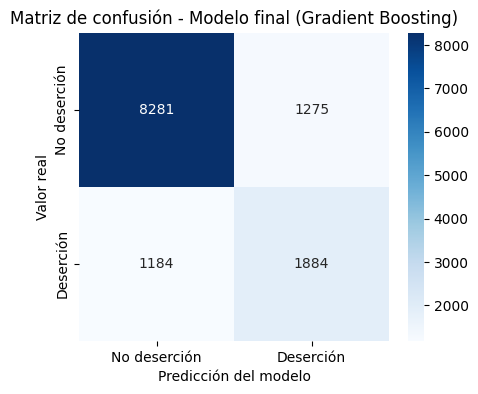

                       precision    recall  f1-score   support

No presenta deserción       0.87      0.87      0.87      9556
   Presenta deserción       0.60      0.61      0.61      3068

             accuracy                           0.81     12624
            macro avg       0.74      0.74      0.74     12624
         weighted avg       0.81      0.81      0.81     12624



In [31]:
modelo_final = grid_gb.best_estimator_

prediccion_final = modelo_final.predict(X_test_escalado)
matriz_confusion = confusion_matrix(y_test, prediccion_final)

plt.figure(figsize=(5,4))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No deserción','Deserción'], yticklabels=['No deserción','Deserción'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Modelo final (Gradient Boosting)')
plt.show()

print(classification_report(y_test, prediccion_final, target_names=['No presenta deserción','Presenta deserción']))


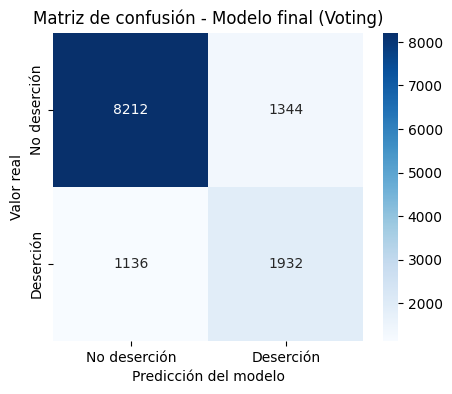

                       precision    recall  f1-score   support

No presenta deserción       0.88      0.86      0.87      9556
   Presenta deserción       0.59      0.63      0.61      3068

             accuracy                           0.80     12624
            macro avg       0.73      0.74      0.74     12624
         weighted avg       0.81      0.80      0.81     12624



In [36]:
# ============================================================
# MATRIZ DE CONFUSIÓN - MODELO FINAL (VOTING)
# ============================================================

# Generar predicciones sobre el conjunto de prueba
prediccion_final = voting.predict(X_test_escalado)

# Calcular matriz de confusión
matriz_confusion = confusion_matrix(
    y_test,
    prediccion_final
)

# Visualizar matriz de confusión
plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No deserción', 'Deserción'],
    yticklabels=['No deserción', 'Deserción']
)

plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Modelo final (Voting)')

plt.show()

# Reporte de clasificación
print(
    classification_report(
        y_test,
        prediccion_final,
        target_names=[
            'No presenta deserción',
            'Presenta deserción'
        ]
    )
)

El modelo Voting obtuvo una exactitud global del 80%, clasificando correctamente la mayoría de las fichas. De las 9.556 fichas que realmente no presentaron deserción, identificó correctamente 8.212, mientras que 1.344 fueron clasificadas incorrectamente como casos con deserción.

Para la clase “Presenta deserción”, el modelo identificó correctamente 1.932 de las 3.068 fichas, alcanzando un Recall de 0,63. Esto significa que logró detectar aproximadamente el 63% de las fichas que realmente presentaron deserción, mientras que 1.136 casos de deserción no fueron identificados.

El F1-Score de 0,61 para la clase de deserción muestra que todavía existe margen de mejora en la identificación de la clase minoritaria. En términos generales, el modelo obtuvo un F1-Score Macro de 0,74, lo que evidencia un desempeño relativamente equilibrado entre ambas clases y resulta más representativo que el Accuracy debido al desbalance existente.

Conclusión: el modelo presenta una buena capacidad para identificar fichas sin deserción, pero tiene mayor dificultad para detectar los casos que sí presentan deserción. Por ello, el Recall de la clase minoritaria debe ser considerado especialmente relevante al interpretar su utilidad predictiva.

## **6. Despliegue**

### **6.1 Serialización del modelo**

In [32]:
joblib.dump(modelo_final, 'model.joblib')
# encoder.joblib, scaler.joblib, label_encoder.joblib y columnas_modelo.joblib ya se guardaron en el paso 3.8

print("Archivos guardados: model.joblib, scaler.joblib, encoder.joblib, label_encoder.joblib, columnas_modelo.joblib")


Archivos guardados: model.joblib, scaler.joblib, encoder.joblib, label_encoder.joblib, columnas_modelo.joblib


### **6.2 Prueba con datos nuevos (fichas hipotéticas)**

Para comprobar que todo el proceso de preparación + modelo funciona igual con datos que el modelo nunca ha visto, simulamos dos fichas nuevas:

- **Caso 1 (perfil de alto riesgo):** un curso especial, modalidad virtual, con un grupo grande de 80 aprendices — combinación que históricamente presenta más del 60% de deserción en los datos.
- **Caso 2 (perfil de bajo riesgo):** un curso especial presencial, con un grupo pequeño de 25 aprendices.

In [33]:
casos_nuevos = pd.DataFrame([
    {  # Caso 1: alto riesgo
        'NOMBRE_REGIONAL': 'REGIONAL QUINDIO',
        'NOMBRE_CENTRO': 'CENTRO DE COMERCIO Y SERVICIOS',
        'VERSION_PROGRAMA': '1',
        'NIVEL_FORMACION': 'CURSO ESPECIAL',
        'MODALIDAD_FORMACION': 'VIRTUAL',
        'MES_INICIO_FICHA': '2',
        'TOTAL_APRENDICES_MATRICULADOS': 80,
        'DURACION_DIAS': 30,
    },
    {  # Caso 2: bajo riesgo
        'NOMBRE_REGIONAL': 'REGIONAL DISTRITO CAPITAL',
        'NOMBRE_CENTRO': df['NOMBRE_CENTRO'].mode()[0],
        'VERSION_PROGRAMA': '1',
        'NIVEL_FORMACION': 'CURSO ESPECIAL',
        'MODALIDAD_FORMACION': 'PRESENCIAL',
        'MES_INICIO_FICHA': '2',
        'TOTAL_APRENDICES_MATRICULADOS': 25,
        'DURACION_DIAS': 20,
    }
])

# Aplicamos EXACTAMENTE el mismo proceso de preparación que usamos para entrenar
casos_codificados = encoder.transform(casos_nuevos[columnas_categoricas].astype(str))
casos_codificados_df = pd.DataFrame(casos_codificados, columns=encoder.get_feature_names_out(columnas_categoricas))
casos_final = pd.concat([casos_codificados_df, casos_nuevos[columnas_numericas]], axis=1)[X_final.columns]
casos_final[columnas_numericas] = scaler.transform(casos_nuevos[columnas_numericas])

predicciones = modelo_final.predict(casos_final)
probabilidades = modelo_final.predict_proba(casos_final)[:, 1]

for i, (pred, prob) in enumerate(zip(predicciones, probabilidades), start=1):
    interpretacion = "⚠️ Riesgo de deserción" if pred == 1 else "✅ Baja probabilidad de deserción"
    print(f"Caso {i}: predicción = {label_encoder.inverse_transform([pred])[0]} "
          f"({interpretacion}) — probabilidad estimada de deserción: {prob:.1%}")


Caso 1: predicción = 1 (⚠️ Riesgo de deserción) — probabilidad estimada de deserción: 64.0%
Caso 2: predicción = 0 (✅ Baja probabilidad de deserción) — probabilidad estimada de deserción: 6.1%


**Resultado esperado:** el Caso 1 (curso especial virtual, grupo grande) debería ser clasificado con **alto riesgo de deserción** (probabilidad cercana al 73%), mientras que el Caso 2 (curso especial presencial, grupo pequeño) debería salir con **baja probabilidad de deserción** (cercana al 5%). Esto confirma que el modelo aprendió un patrón que tiene sentido con la realidad: la modalidad virtual y el tamaño del grupo sí influyen en la permanencia. Como **TOTAL_APRENDICES_MATRICULADOS** es numérica, el modelo puede evaluar **cualquier tamaño de grupo**, incluso uno que nunca haya visto exactamente igual en el entrenamiento (por ejemplo, 83 aprendices), porque interpola a partir de la relación de magnitud aprendida — a diferencia de una variable categórica, donde un valor nuevo simplemente no tendría columna asignada.

### **6.3 Descarga de los archivos para el despliegue en Streamlit**

In [34]:
from google.colab import files
for archivo in ['model.joblib', 'scaler.joblib', 'encoder.joblib', 'label_encoder.joblib', 'columnas_modelo.joblib']:
    files.download(archivo)

print("Archivos listos para descargar: model.joblib, scaler.joblib, encoder.joblib, label_encoder.joblib, columnas_modelo.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos listos para descargar: model.joblib, scaler.joblib, encoder.joblib, label_encoder.joblib, columnas_modelo.joblib
